In [1]:
!pip install -q \
numpy==1.26.4 \
torch==2.2.2 \
torchvision==0.17.2 \
torchaudio==2.2.2 \
transformers==4.44.2 \
accelerate==0.33.0 \
datasets==2.19.1 \
evaluate \
jiwer \
librosa \
soundfile

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 864.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/

In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
import torch
import transformers
import accelerate
import datasets

print(torch.__version__)
print(transformers.__version__)
print(accelerate.__version__)
print(datasets.__version__)
print(torch.cuda.is_available())

2.2.2+cu121
4.44.2
0.33.0
2.19.1
True


In [2]:
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor

MODEL_NAME = "nijatzeynalov/wav2vec2-large-mms-1b-azerbaijani-common_voice15.0"

processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
model = Wav2Vec2ForCTC.from_pretrained(MODEL_NAME)

# Yaddas problem etdi, deyisiklik burada etdim
model.freeze_feature_encoder()
model.gradient_checkpointing_enable()
model.config.use_cache = False

print("MODEL LOADED & FROZEN OK")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/30.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/96.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

MODEL LOADED & FROZEN OK


In [3]:
from datasets import load_dataset, Audio

dataset = load_dataset("tahmaz/azerbaijani-asr-fl", split="train")

# RAM + VRAM ucun kicildirik (evvel 450 test etdim, 15GB tez doldu xeta aldim)
dataset = dataset.select(range(120))

dataset = dataset.train_test_split(test_size=0.1)

print(dataset)

Generating train split:   0%|          | 0/2665 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/400 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/923 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['audio_file', 'text', 'duration'],
        num_rows: 108
    })
    test: Dataset({
        features: ['audio_file', 'text', 'duration'],
        num_rows: 12
    })
})


In [4]:
audio_col = "audio_file" if "audio_file" in dataset["train"].column_names else "audio"
text_col = "text"

dataset = dataset.cast_column(audio_col, Audio(sampling_rate=16000))

print("audio_col:", audio_col)
print(dataset["train"].column_names)

audio_col: audio_file
['audio_file', 'text', 'duration']


In [5]:
def preprocess(batch):
    audio = batch[audio_col]

    inputs = processor(
        audio["array"],
        sampling_rate=16000
    )

    return {
        "input_values": inputs.input_values[0],
        "labels": processor.tokenizer(batch[text_col]).input_ids
    }

In [6]:
dataset = dataset.map(
    preprocess,
    num_proc=1,
    remove_columns=dataset["train"].column_names
)

Map:   0%|          | 0/108 [00:00<?, ? examples/s]

Map:   0%|          | 0/12 [00:00<?, ? examples/s]

In [7]:
import torch

class DataCollatorCTC:
    def __init__(self, processor):
        self.processor = processor

    def __call__(self, features):
        # ses melumatlarini toplayiriq
        input_values = [{"input_values": f["input_values"]} for f in features]
        # metn melumatlarini toplayiriq
        labels = [{"input_ids": f["labels"]} for f in features]

        # ses melumatlarini bir array halina saliriq
        batch = self.processor.pad(input_values, return_tensors="pt")

        # metn melumatlarini bir array halina saliriq
        labels_batch = self.processor.tokenizer.pad(labels, return_tensors="pt")

        # labeling edirik
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        batch["labels"] = labels
        return batch

data_collator = DataCollatorCTC(processor)

In [8]:
import evaluate
import numpy as np

wer_metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids = np.argmax(pred.predictions, axis=-1)

    pred.label_ids[pred.label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.batch_decode(pred_ids)
    label_str = processor.batch_decode(pred.label_ids, group_tokens=False)

    return {"wer": wer_metric.compute(predictions=pred_str, references=label_str)}

In [9]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./asr_model",

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,

    eval_strategy="steps",
    eval_steps=50,
    save_steps=50,
    logging_steps=20,

    num_train_epochs=2,

    fp16=True,
    gradient_checkpointing=True,

    learning_rate=1e-4,
    report_to="none",

    # adamw_torch yerine "adafactor" yaziriq, digeri uygun olmadi
    optim="adafactor",
)

In [10]:
from transformers import Trainer

trainer = Trainer(
    model=model,

    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],

    tokenizer=processor.feature_extractor,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [11]:
print("Baseline qiymətləndirilir (fine-tune əvvəli)...")
baseline = trainer.evaluate()
baseline_wer = baseline["eval_wer"]
print(f"Baseline WER: {baseline_wer*100:.2f}%")

Baseline qiymətləndirilir (fine-tune əvvəli)...


Baseline WER: 39.27%


In [12]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:460: UserWarning: torch.utils.checkpoint: please pass in use_reentrant=True or use_reentrant=False explicitly. The default value of use_reentrant will be updated to be False in the future. To maintain current behavior, pass use_reentrant=True. It is recommended that you use use_reentrant=False. Refer to docs for more details on the differences between the two variants.
  warnings.warn(


Step,Training Loss,Validation Loss,Model Preparation Time,Wer
50,0.659800,0.370049,0.012000,0.471204


/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:460: UserWarning: torch.utils.checkpoint: please pass in use_reentrant=True or use_reentrant=False explicitly. The default value of use_reentrant will be updated to be False in the future. To maintain current behavior, pass use_reentrant=True. It is recommended that you use use_reentrant=False. Refer to docs for more details on the differences between the two variants.
  warnings.warn(


TrainOutput(global_step=54, training_loss=0.7257317790278682, metrics={'train_runtime': 366.3176, 'train_samples_per_second': 0.59, 'train_steps_per_second': 0.147, 'total_flos': 2.4319261450692864e+17, 'train_loss': 0.7257317790278682, 'epoch': 2.0})

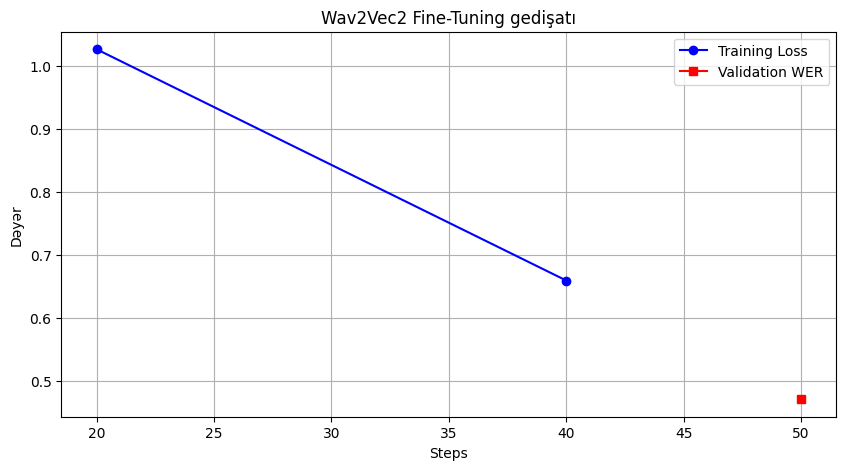

In [13]:
import matplotlib.pyplot as plt

history = trainer.state.log_history

# Loss ve WER melumatlarini ayiririq
train_steps = [x['step'] for x in history if 'loss' in x]
train_loss = [x['loss'] for x in history if 'loss' in x]

eval_steps = [x['step'] for x in history if 'eval_wer' in x]
eval_wer = [x['eval_wer'] for x in history if 'eval_wer' in x]

plt.figure(figsize=(10, 5))

# Loss ucun qrafik
plt.plot(train_steps, train_loss, label='Training Loss', marker='o', color='blue')

# WER ucun qrafik
if eval_steps:
    plt.plot(eval_steps, eval_wer, label='Validation WER', marker='s', color='red')

plt.title('Wav2Vec2 Fine-Tuning gedişatı')
plt.xlabel('Steps')
plt.ylabel('Dəyər')
plt.legend()
plt.grid(True)
plt.show()

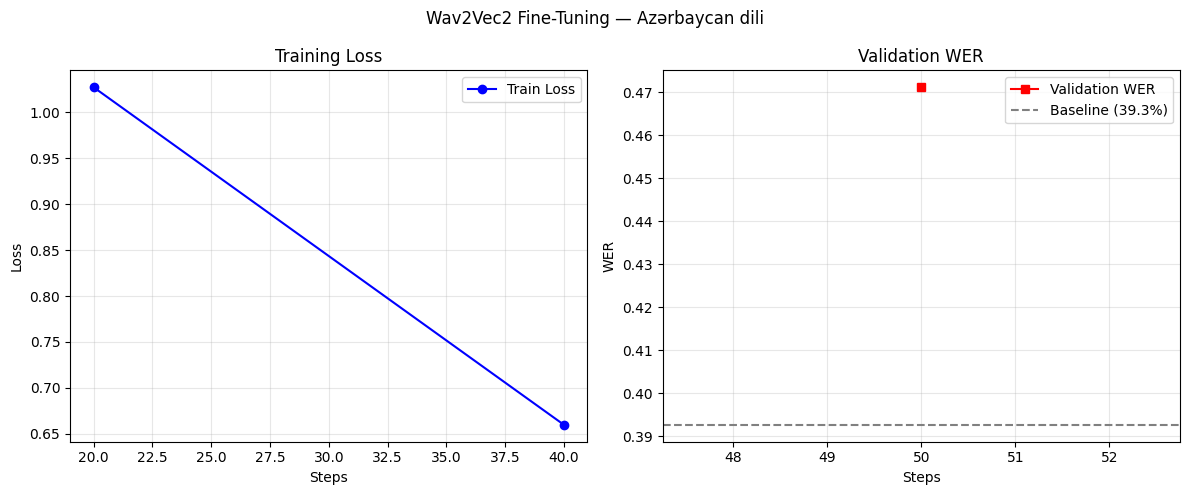


Baseline WER : 39.27%
Final WER    : 47.12%
İyiləşmə     : -7.85% azalma


In [14]:
import matplotlib.pyplot as plt, os

history = trainer.state.log_history
train_steps   = [x["step"]     for x in history if "loss"     in x]
train_loss    = [x["loss"]     for x in history if "loss"     in x]
eval_steps    = [x["step"]     for x in history if "eval_wer" in x]
eval_wer_vals = [x["eval_wer"] for x in history if "eval_wer" in x]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_steps, train_loss, marker="o", color="blue", label="Train Loss")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Steps")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

if eval_steps:
    axes[1].plot(eval_steps, eval_wer_vals, marker="s", color="red", label="Validation WER")
    axes[1].axhline(baseline_wer, color="gray", linestyle="--",
                    label=f"Baseline ({baseline_wer*100:.1f}%)")
    axes[1].set_title("Validation WER")
    axes[1].set_xlabel("Steps")
    axes[1].set_ylabel("WER")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

plt.suptitle("Wav2Vec2 Fine-Tuning — Azərbaycan dili")
plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/training_plot.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nBaseline WER : {baseline_wer*100:.2f}%")
final_wer = eval_wer_vals[-1] if eval_wer_vals else None
if final_wer:
    print(f"Final WER    : {final_wer*100:.2f}%")
    print(f"İyiləşmə     : {(baseline_wer - final_wer)*100:.2f}% azalma")